<a href="https://colab.research.google.com/github/PrashantBagri/IP_IIIT_Delhi_2026/blob/main/non_quantized_descrete_weights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tempfile
import os

import tensorflow as tf
from tensorflow import keras

In [2]:
import numpy as np
import tensorflow as tf

try:
    import tf_keras as keras
except ImportError:
    from tensorflow import keras

tf.random.set_seed(42)
np.random.seed(42)

In [3]:
# Load MNIST
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize to [0,1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Match paper setup: use 50k training samples
x_train = x_train_full[:50000]
y_train = y_train_full[:50000]

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)

Train: (50000, 28, 28) (50000,)
Test : (10000, 28, 28) (10000,)


In [4]:
def build_float_ann():
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation="sigmoid"),
        keras.layers.Dense(10)   # logits
    ])
    return model

float_model = build_float_ann()
float_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101770 (397.54 KB)
Trainable params: 101770 (397.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [5]:
float_model = build_float_ann()

float_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

# Train model
float_history = float_model.fit(
    x_train, y_train,
    epochs=40,
    batch_size=32,
    verbose=1
)

float_test_loss, float_test_acc = float_model.evaluate(x_test, y_test, verbose=0)

print(f"FLOAT Test accuracy: {float_test_acc:.4f} | loss: {float_test_loss:.4f}")

Epoch 1/40
1563/1563 [==============================] - 7s 4ms/step - loss: 0.4336 - accuracy: 0.8879
Epoch 2/40
1563/1563 [==============================] - 5s 3ms/step - loss: 0.2159 - accuracy: 0.9378
Epoch 3/40
1563/1563 [==============================] - 6s 4ms/step - loss: 0.1612 - accuracy: 0.9525
Epoch 4/40
1563/1563 [==============================] - 5s 3ms/step - loss: 0.1276 - accuracy: 0.9624
Epoch 5/40
1563/1563 [==============================] - 6s 4ms/step - loss: 0.1033 - accuracy: 0.9700
Epoch 6/40
1563/1563 [==============================] - 5s 3ms/step - loss: 0.0853 - accuracy: 0.9759
Epoch 7/40
1563/1563 [==============================] - 7s 5ms/step - loss: 0.0705 - accuracy: 0.9806
Epoch 8/40
1563/1563 [==============================] - 5s 3ms/step - loss: 0.0591 - accuracy: 0.9841
Epoch 9/40
1563/1563 [==============================] - 6s 4ms/step - loss: 0.0502 - accuracy: 0.9869
Epoch 10/40
1563/1563 [==============================] - 6s 4ms/step - loss: 0.042

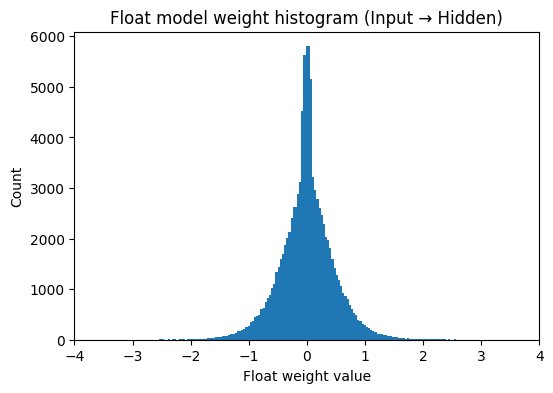

In [6]:
import matplotlib.pyplot as plt

dense_layers = [layer for layer in float_model.layers if isinstance(layer, keras.layers.Dense)]

# Only input -> hidden weights
w1 = dense_layers[0].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w1, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Input → Hidden)")
plt.xlim([-4, 4])
plt.show()

In [7]:
float_history.model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_2 (Dense)             (None, 128)               100480    
                                                                 
 dense_3 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101770 (397.54 KB)
Trainable params: 101770 (397.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [8]:
layer_weights, biases = float_model.get_layer('dense_2').get_weights()
print(layer_weights)
#weights only for one layer

[[ 0.00624967  0.02062793  0.0470041  ...  0.07398947  0.0688447
  -0.06694937]
 [ 0.04483018 -0.0186212   0.02160546 ... -0.0057649  -0.01057561
  -0.06379011]
 [-0.03412021 -0.04461669  0.02581963 ...  0.03427172  0.00106086
   0.05370619]
 ...
 [ 0.03193803  0.05085628 -0.03057774 ... -0.00874298 -0.04954335
   0.07363804]
 [-0.00216732 -0.02884126 -0.01738849 ...  0.06548215  0.07170568
  -0.0395182 ]
 [-0.02118143  0.07396642  0.00696407 ... -0.03203186  0.04910973
  -0.03227443]]


In [9]:
levels = [-1.0 , -0.75, -0.25, 0.0 , 0.25, 0.75, 1.0]


def snap_weights_to_levels(weights, levels):


    levels = np.array(levels)
    snapped = np.zeros_like(weights)

    for i in range(weights.shape[0]):
        for j in range(weights.shape[1]):
            w = weights[i, j]


            if w <= levels[0]:
                snapped[i, j] = levels[0]
                continue
            if w >= levels[-1]:
                snapped[i, j] = levels[-1]
                continue


            for k in range(len(levels) - 1):
                low = levels[k]
                high = levels[k + 1]

                if low <= w <= high:
                    midpoint = (low + high) / 2

                    if w > midpoint:
                        snapped[i, j] = high
                    else:
                        snapped[i, j] = low
                    break

    return snapped



In [10]:
snapped_weights = snap_weights_to_levels(layer_weights, levels)

In [11]:
float_model.get_layer('dense_2').set_weights([snapped_weights, biases])

In [12]:
loss, acc = float_model.evaluate(x_test, y_test)
print("Accuracy:", acc)

313/313 [==============================] - 1s 2ms/step - loss: 0.1537 - accuracy: 0.9669
Accuracy: 0.9668999910354614


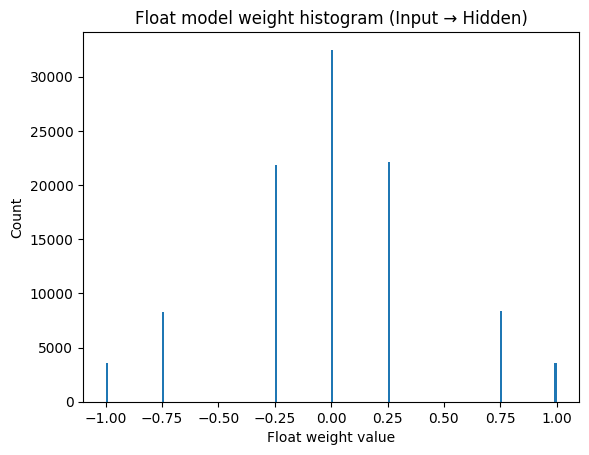

In [13]:
import matplotlib.pyplot as plt

dense_layers = [layer for layer in float_model.layers if isinstance(layer, keras.layers.Dense)]

# Only input -> hidden weights
w1 = dense_layers[0].get_weights()[0].reshape(-1)


plt.hist(w1, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Input → Hidden)")
plt.show()

In [14]:
float_history = float_model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
1563/1563 [==============================] - 7s 4ms/step - loss: 0.0026 - accuracy: 0.9994
Epoch 2/5
1563/1563 [==============================] - 6s 4ms/step - loss: 3.2453e-04 - accuracy: 1.0000
Epoch 3/5
1563/1563 [==============================] - 7s 5ms/step - loss: 2.3000e-04 - accuracy: 1.0000
Epoch 4/5
1563/1563 [==============================] - 6s 4ms/step - loss: 1.9393e-04 - accuracy: 1.0000
Epoch 5/5
1563/1563 [==============================] - 6s 4ms/step - loss: 0.0012 - accuracy: 0.9996


In [15]:
float_test_loss, float_test_acc = float_model.evaluate(x_test, y_test, verbose=0)
float_test_acc

0.9768000245094299

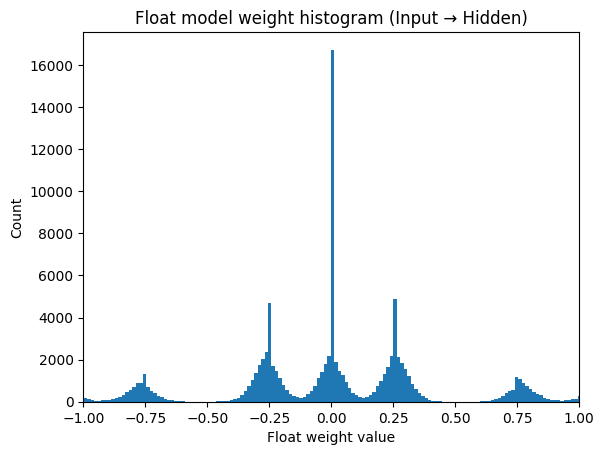

In [16]:
import matplotlib.pyplot as plt

dense_layers = [layer for layer in float_model.layers if isinstance(layer, keras.layers.Dense)]

# Only input -> hidden weights
w1 = dense_layers[0].get_weights()[0].reshape(-1)


plt.hist(w1, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Input → Hidden)")
plt.xlim([-1, 1])
plt.show()

In [17]:
layer_weights_2, biases_2 = float_model.get_layer('dense_3').get_weights()
print(layer_weights_2)
#weights only for one layer

[[ 0.6385734   1.2493777  -1.4335564  ... -0.09888092 -0.3269314
  -2.2544785 ]
 [-1.8656561   1.9108218   0.6271215  ... -2.3344386  -1.5408841
  -0.68003   ]
 [ 2.022644    0.5953958   2.3771667  ... -0.7496056  -1.7453147
   0.32840738]
 ...
 [-0.34804904  0.20903735  0.48230046 ... -0.68511295  1.0100033
   1.7929771 ]
 [ 0.61552745 -0.93301743 -0.31392255 ... -1.4785827   0.35091856
   1.1519697 ]
 [ 0.88176453  0.28362787 -0.06801842 ...  0.080338    0.09498264
   0.7494655 ]]


In [18]:
snapped_weights_2 = snap_weights_to_levels(layer_weights_2, levels)
snapped_weights_2

array([[ 0.75,  1.  , -1.  , ...,  0.  , -0.25, -1.  ],
       [-1.  ,  1.  ,  0.75, ..., -1.  , -1.  , -0.75],
       [ 1.  ,  0.75,  1.  , ..., -0.75, -1.  ,  0.25],
       ...,
       [-0.25,  0.25,  0.25, ..., -0.75,  1.  ,  1.  ],
       [ 0.75, -1.  , -0.25, ..., -1.  ,  0.25,  1.  ],
       [ 1.  ,  0.25,  0.  , ...,  0.  ,  0.  ,  0.75]], dtype=float32)

In [19]:
float_model.get_layer('dense_3').set_weights([snapped_weights_2, biases_2])

In [20]:
# snapped_weights_3 = snap_weights_to_levels(layer_weights_2, levels)
# snapped_weights_3

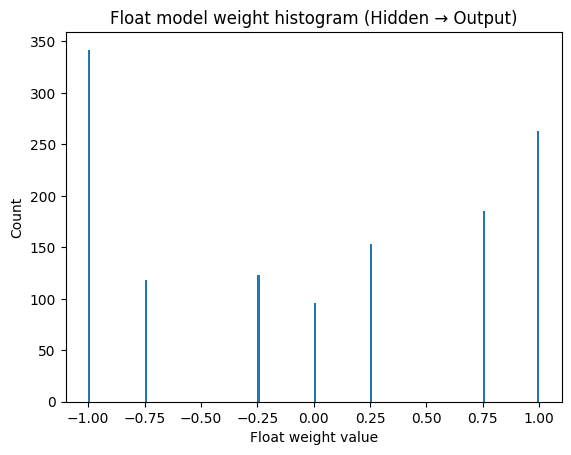

In [21]:
import matplotlib.pyplot as plt

dense_layers = [layer for layer in float_model.layers if isinstance(layer, keras.layers.Dense)]

# Only hidden -> output weights
w1 = dense_layers[1].get_weights()[0].reshape(-1)


plt.hist(w1, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden → Output)")
plt.show()

In [22]:
float_history = float_model.fit(
    x_train, y_train,
    epochs=1,
    batch_size=32,
    verbose=1
)

1563/1563 [==============================] - 6s 4ms/step - loss: 0.0053 - accuracy: 0.9995


In [23]:
float_test_loss, float_test_acc = float_model.evaluate(x_test, y_test, verbose=0)
float_test_acc

0.9757000207901001

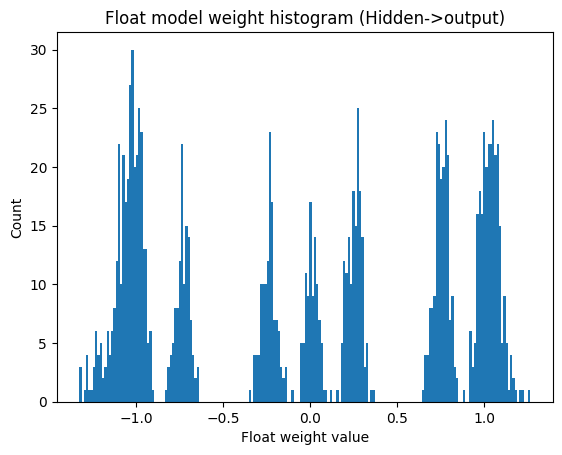

In [24]:
import matplotlib.pyplot as plt

dense_layers = [layer for layer in float_model.layers if isinstance(layer, keras.layers.Dense)]

# Only input -> hidden weights
w1 = dense_layers[1].get_weights()[0].reshape(-1)


plt.hist(w1, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden->output)")
# plt.xlim([-1, 1])
plt.show()